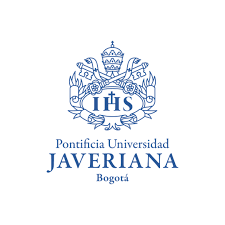
# ***Pontificia Universidad Javeriana***

# **2nd Partial: Use Keras – Water Quality Prediction**
**Course:** High Volume Data Processing

**Author:** Juan Diego Muñoz Angulo

**Date:** April 2026


## **Problematic**

Water treatment must be essential to guarantee purity and quality. One of the significant elements is to apply the concepts of High Volume Data Processing to solve this type of problems that affect public health. This example is intended to consider a methodology for applying PAVD to diagnose/predict water quality in India.

## **Aim**

Build a data processing pipeline with PySpark and train a model with Keras to predict the water quality index (WQI), evaluating its performance with metrics and comparing it against baselines.

## **Methodology (summary)**

1. Data import (CSV) and Spark session preparation.

2. Preprocessing: types, nulls, cleaning and EDA.

3. Construction of variables (WQI and quality ranges).

4. Training models with Keras.

5. Evaluation: MAE, RMSE, $R^2$ and comparison with base models.


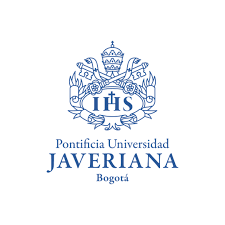
# ***Pontificia Universidad Javeriana***

# **2do Parcial: Uso Keras – Predicción de Calidad del Agua**
**Curso:** Procesamiento de Alto Volumen de Datos  

**Autor:** Juan Diego Muñoz Angulo  

**Fecha:** Abril 2026  


## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodología para aplicar PAVD para diagnosticar/predicir la calidad del agua en la India.

## **Objetivo**

Construir un pipeline de tratamiento de datos con PySpark y entrenar un modelo con Keras para predecir el índice de calidad del agua (WQI), evaluando su desempeño con métricas y comparándolo contra baselines.

## **Metodología (resumen)**

1. Importación de datos (CSV) y preparación de sesión Spark.

2. Preprocesamiento: tipos, nulos, limpieza y EDA.

3. Construcción de variables (WQI y rangos de calidad).

4. Entrenamiento de modelos con Keras.

5. Evaluación: MAE, RMSE, $R^2$ y comparación con modelos base.


**Referencia WQI:** https://www.intechopen.com/chapters/69568

## **1.- Import of libraries**

## **1.- Importación de bibliotecas**

# Raising pip environment variables

# Levantamiento de variables de entorno pip


In [ ]:
import os
import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *


import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

ModuleNotFoundError: No module named 'numpy'

### SPARK session removal

### Levantamiento de sesión SPARK


In [ ]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Munoz")

sparkMunoz = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkMunoz.sparkContext, sparkSession=sparkMunoz)


print("Sesion creada: ProcesamientoDatos04!!!")

sparkMunoz

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 10:20:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04!!!


##**2.- Data Loading from HADOOP HDFS**

##**2.- Carga de Datos desde el HADOOP HDFS**

In [ ]:
# Opcion A, Cluster
df00 = sparkMunoz.read.format("csv").option("header", "true").load("/Almacen/waterquality.csv")

# Opcion B, Local por si clonaste el repositorio dond puse esto
#df00 = (sparkMunoz.read.format("csv")
#        .option("header", "true")
#        .option("inferSchema", "true")
#        .load("waterquality.csv"))

df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Data Analysis and Preparation**

Data (csv) are presented with the different parameters of the rivers of India. Each parameter is the average of the values ​​measured over a period of time. The data has been extracted from the official website of India (RiverIndia)

- Data types: data type consistency, transformation
- Columns: knowledge of columns, elimination.
- Analysis of null or impossible data: awareness.

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [ ]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Measurement station code
- LOCATIONS: river locations
- STATE: State of India
- TEMP: Water temperature in °C
- DO: Dissolved Oxygen (mg/L). High oxygen concentrations represent better water quality.
- pH: Negative logarithm of the hydrogen concentration. Dimensionless number to indicate the acidity of water.
- CONDUCTIVITY: Measures the ability of a solution to conduct current. Pure water is NOT a conductor of current.
- BOD: Bacteria and other microorganisms that use organic substances as food: Biochemical Oxygen Demand. Greater amount of organic material, greater BOD.
- NITRATE_N_NITRITE_N: Nitrates/Nitrites "nitrogen". High concentrations of nitrogen at the water surface can stimulate the rapid growth of algae which degrade water quality (mg/L).
- FECAL_COLIFORM: Average coliform bacteria: excretions.
- TOTAL_COLIFORM']: It will be eliminated as it does not contribute to the water quality prediction study.

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Data statistics are presented below:**

**Se presenta las estadísticas de los datos a continuación:**


In [ ]:
for valor in df00.columns:
    df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|
+-------+-----------------+

+-------+-------------------+
|summary|NITRATE_N_NITRITE_N|
+-------+-------------------+
|  count|                534|
|   mean| 1.3785714285714301|
| stddev|  2.803947753154703|
|    min|                  0|
|    max|                 NA|
+-------+-------------------+

+-------+-----------------+
|summary|   FECAL_COLIFORM|
+-------+-----------------+
|  count|              534|
|   mean|7384.170353982301|
| stddev|30714.05963523712|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|    TOTAL_COLIFORM|
+-------+------------------+
|  count|               534|
|   mean|124396.96767676767|
| stddev|1458407.8189939584|
|    min|                 1|
|    max|           

## **Display of NULL DATA**

#Number of Null or Impossible Values

## **Visualización de los DATOS NULOS**

#Cantidad de Valores Nulos o Imposibles


In [ ]:
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



- It is observed that there are no null or impossible data.
- Each of the dimensions is graphed.
- A temporary view is created to facilitate visualizations with SQL in Spark.

- Se observa que no hay datos nulos o imposibles.
- Se procede a graficar cada una de las dimensiones.
- Se crea una vista temporal para facilitar las visualizaciones con SQL en Spark.

In [ ]:
df00.createOrReplaceTempView("df00_sql")

df01 = sparkMunoz.sql('''Select * from df00_sql where TEMP is not null and
       DO is not null and
       pH is not null and
       CONDUCTIVITY is not null and
       BOD is not null and
       NITRATE_N_NITRITE_N is not null and
       FECAL_COLIFORM is not null''')


The number of null or impossible values ​​is checked again (after filtering).

Se verifica nuevamente la cantidad de valores nulos o imposibles (después del filtrado).

In [ ]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Data processing**
The data types are changed.

### **Tratamiento de datos**
Se procede a cambiar los tipos de datos.

In [ ]:
df00.dtypes

df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))

df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))

df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))

df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))

df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))

df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))

df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

df00.dtypes



[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float'),
 ('TOTAL_COLIFORM', 'string')]

In [ ]:
df01 = df00.drop('TOTAL_COLIFORM')

df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## **Creation of Tables to Visualize Data**

In this part, auxiliary tables/queries are prepared to display and summarize the data (for example, by parameter or by state).
- *lambda* type functions are used to support data processing/cleaning.
- A query is created for each parameter (for example DO).
- A vector/structure is constructed per parameter for ease of visualization.

## **Creación de Tablas para Visualizar los Datos**

En esta parte se preparan tablas/consultas auxiliares para visualizar y resumir los datos (por ejemplo, por parámetro o por estado).
- Se hace uso de funciones tipo *lambda* para apoyar el tratamiento/limpieza de los datos.
- Se crea una consulta por cada parámetro (por ejemplo DO).
- Se construye un vector/estructura por parámetro para facilitar la visualización.

In [ ]:
df01.createOrReplaceTempView("df01_sql")

parametros = ["pH", "CONDUCTIVITY", "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"]

# DO
do_parametro = sparkMunoz.sql("Select DO from df01_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

# pH
ph_parametro = sparkMunoz.sql("Select pH from df01_sql")
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()

# CONDUCTIVITY
conductivity_parametro = sparkMunoz.sql("Select CONDUCTIVITY from df01_sql")
conductivity_parametro = conductivity_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()

# BOD
bod_parametro = sparkMunoz.sql("Select BOD from df01_sql")
bod_parametro = bod_parametro.rdd.map(lambda fila: fila.BOD).collect()

# NITRATE_N_NITRITE_N
nitrate_parametro = sparkMunoz.sql("Select NITRATE_N_NITRITE_N from df01_sql")
nitrate_parametro = nitrate_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()

# FECAL_COLIFORM
fecal_parametro = sparkMunoz.sql("Select FECAL_COLIFORM from df01_sql")
fecal_parametro = fecal_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()


* Graph the parameters to know their characteristics: DO and PH

* Grafica Los parámetros para conocer sus características: DO y PH


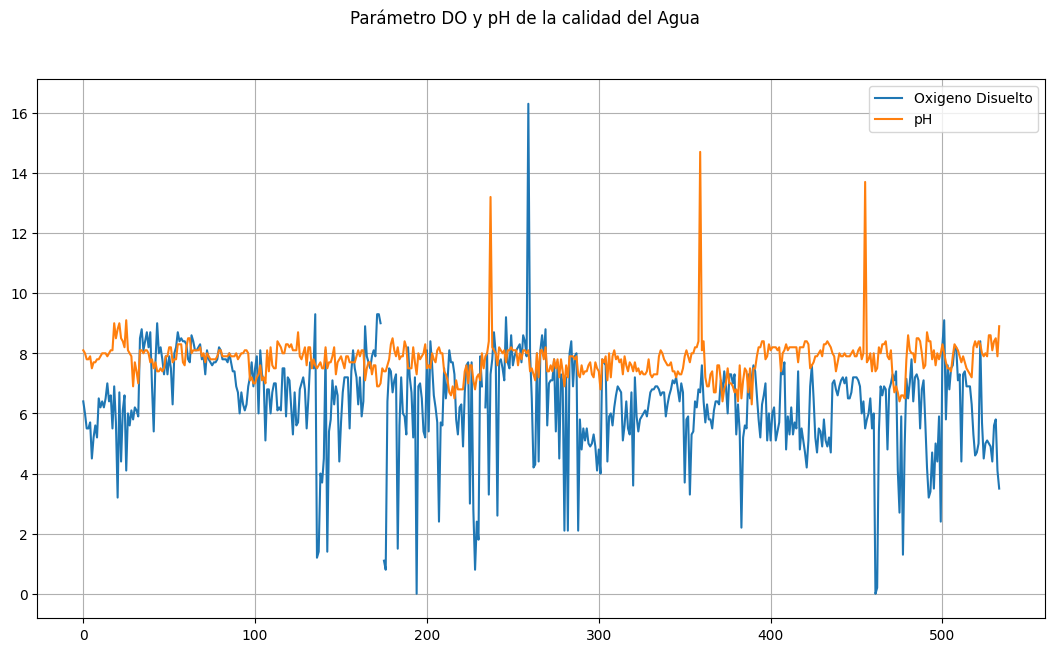

In [ ]:


tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')

ax1.plot(range(0,tam), ph_parametro, label='pH')

fig.suptitle('Parámetro DO y pH de la calidad del Agua')

legend=ax1.legend()

plt.grid()

plt.show()


**Graphic (DO vs pH)**

- This figure compares the behavior of dissolved oxygen (DO) and pH across the samples.
- The X axis represents the sample index and the Y axis represents the parameter value.
- If both curves remain relatively stable, it suggests that there are no sudden changes in those measurements.
- Sharp spikes or drops in DO or pH can indicate points where water quality changes and it is worth reviewing those records in more detail.
- This visualization is exploratory, it is used to understand general trends before calculating the WQI and training the model.

**Gráfica (DO vs pH)**

- Esta figura compara el comportamiento del oxígeno disuelto (DO) y del pH a lo largo de las muestras.
- El eje X representa el índice de muestra y el eje Y el valor del parámetro.
- Si ambas curvas se mantienen relativamente estables, sugiere que no hay cambios bruscos en esas mediciones.
- Picos o caídas fuertes en DO o pH pueden indicar puntos donde la calidad del agua cambia y conviene revisar esos registros con más detalle.
- Esta visualización es exploratoria, sirve para entender tendencias generales antes de calcular el WQI y entrenar el modelo.

* ###Graph The parameters to know their characteristics: BOD and Nitrogens

* ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos


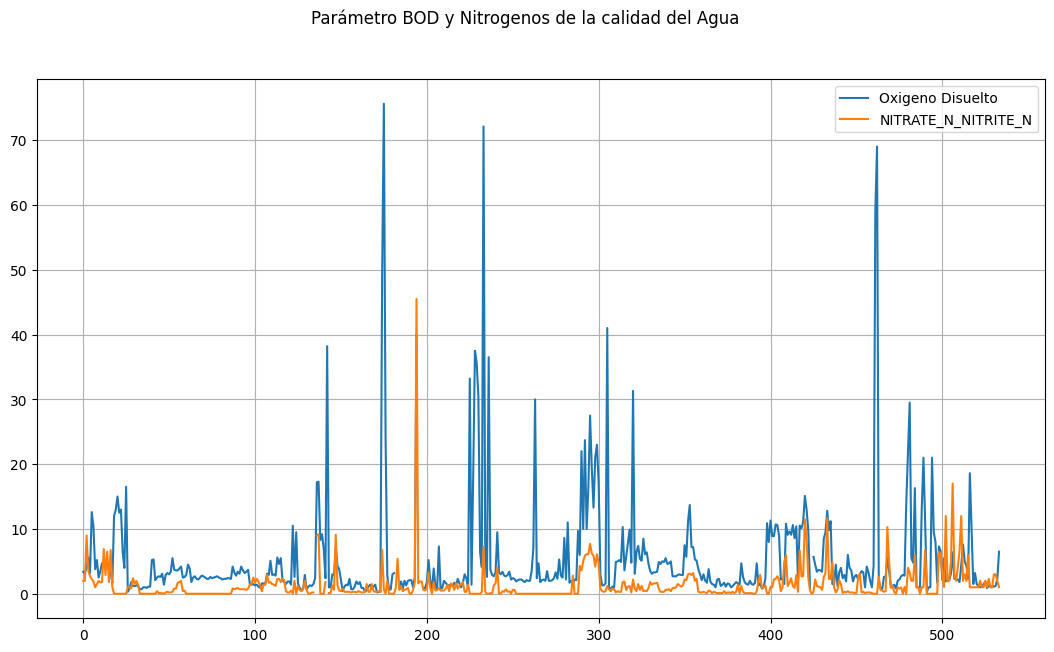

In [ ]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), bod_parametro, label='Oxigeno Disuelto')

ax1.plot(range(0,tam), nitrate_parametro, label='NITRATE_N_NITRITE_N')

fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')

legend=ax1.legend()

plt.grid()
plt.show()

**Graph (BOD vs Nitrates/Nitrites)**

- This figure shows the joint variation of BOD and `NITRATE_N_NITRITE_N` across the samples.
- The X axis represents the sample index and the Y axis the value of each parameter.
- If both parameters rise in the same reaches, it may suggest additional pressure on water quality at those points.
- Sudden changes or isolated peaks are useful to detect areas/periods that should be reviewed in more detail.
- This graph is descriptive and serves as support prior to calculating the WQI.

**Gráfica (BOD vs Nitratos/Nitritos)**

- Esta figura muestra la variación conjunta de BOD y de `NITRATE_N_NITRITE_N` a lo largo de las muestras.
- El eje X representa el índice de muestra y el eje Y el valor de cada parámetro.
- Si ambos parámetros suben en los mismos tramos, puede sugerir presión adicional sobre la calidad del agua en esos puntos.
- Cambios bruscos o picos aislados son útiles para detectar zonas/periodos que conviene revisar con más detalle.
- Esta gráfica es descriptiva y sirve como apoyo previo al cálculo del WQI.

### Graph the parameters to know their characteristics: FC and Conductivity

### Grafica Los parámetros para conocer sus características: FC y Conductividad


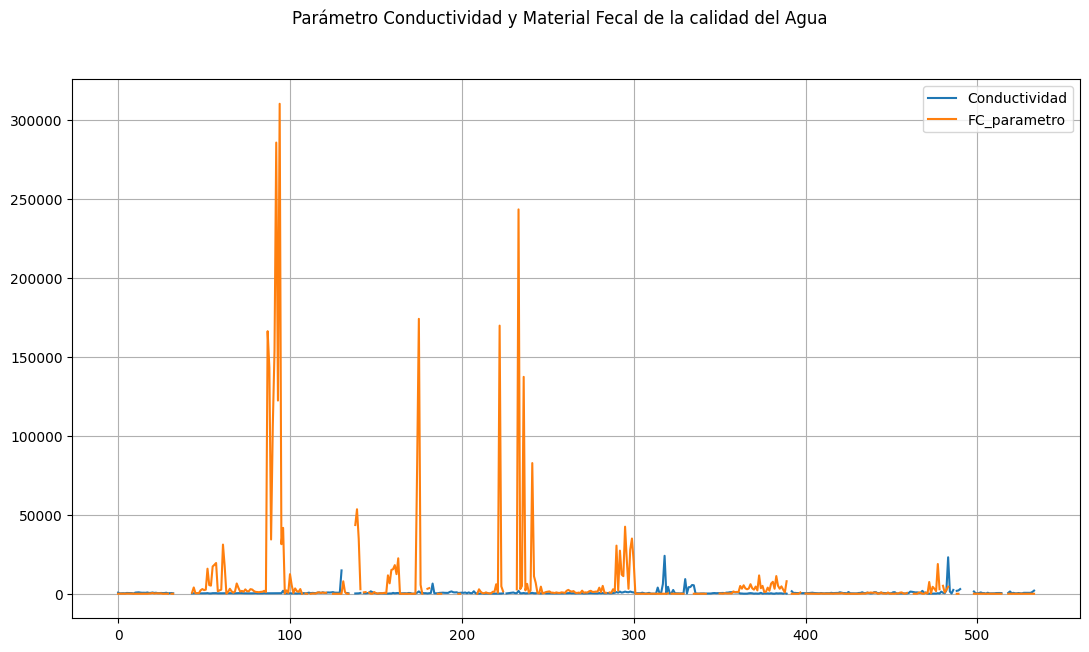

In [ ]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), conductivity_parametro, label='Conductividad')

ax1.plot(range(0,tam), fecal_parametro, label='FC_parametro')

fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')

legend=ax1.legend()


plt.grid()

plt.show()


**Graph (Conductivity vs Fecal Material)**

- This figure compares the conductivity of water with the fecal material indicator (`FECAL_COLIFORM`).
- The X axis is the sample index and the Y axis corresponds to the measured value of each variable.
- Sections with high conductivity and/or increases in fecal material may be associated with lower water quality.
- If one curve remains stable and the other presents peaks, those points deserve specific validation.
- As in the other parameter plots, the objective here is exploratory to understand the general behavior of the data.

**Gráfica (Conductividad vs Material Fecal)**

- Esta figura compara la conductividad del agua con el indicador de material fecal (`FECAL_COLIFORM`).
- El eje X es el índice de muestra y el eje Y corresponde al valor medido de cada variable.
- Tramos con conductividad alta y/o incrementos en material fecal pueden asociarse con menor calidad del agua.
- Si una curva se mantiene estable y la otra presenta picos, esos puntos merecen validación puntual.
- Igual que en las otras gráficas de parámetros, el objetivo aquí es exploratorio para entender el comportamiento general de los datos.

User-defined function to define the range of water quality based on pH
Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

Función definida por el usuario para definir el rango de calidad de agua según el pH
Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)


In [ ]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).
       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).
       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).
       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* ### User-defined function to define the range of water quality according to DO

* ### Función definida por el usuario para definir el rando de la calidad del agua según DO

In [ ]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
                   when((df01.DO>=5.1) & (df01.DO<6.0), 80).
                   when((df01.DO>=4.1) & (df01.DO<5.0), 60).
                   when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* ### User defined function to define the range of water quality according to COND

* ### Función definida por el usuario para definir el rando de la calidad del agua según COND


In [ ]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
         when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
         when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
         when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### User defined function to define the range of water quality according to BOD

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD


In [ ]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                    when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                    when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                    when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

* ### User defined function to define the water quality range based on NITRATE_N_NITRITE_N
    * ### 100: Fresh Water
    * ### 80: Moderate Water
    * ### 60: Hard Water
    * ### 40: Very Hard Water

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura


In [ ]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                    when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                    when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                    when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

* ### User defined function to define the range of water quality based on Fecal Material
  *  ### 100: Fresh Water
  *  ### 80: Moderate Water
  *  ### 60: Hard Water
  *  ### 40: Very Hard Water

* df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
   *                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
   *                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
   *                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

* df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
   *                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
   *                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
   *                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

In [ ]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                   when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                   when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                   when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

##**The dataframe object df02 contains up to now all the calculations and records about the water quality ranges**

##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**


In [ ]:
# A continuación se hace una inspección en general del df02
df02.show(10)
# Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creation of columns that contain the Quality Index according to the bibliographic reference**

A new dataframe object is created with the new Quality Index columns

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [ ]:
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)
df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculation of Water Quality Index**

   - The WQI column is created: it represents the quality index, but the NOTE TO HIGHLIGHT is that according to the literature, there is too little data for it to reflect a reliable value. That is, as an example study, IT IS NOT A GUIDE TO BE TAKEN INTO ACCOUNT FOR WATER QUALITY.

   - df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   - df04.show(10)

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

   - df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   - df04.show(10)

In [ ]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Index Intervals for WQI**

- Excellent: fresh water ***WQI = [0.0, 25.0]***
- Good: moderate water ***WQI = (25.0, 50.0]***
- Low: hard water ***WQI = (50.0, 75.0]***
- Very_Low: very hard water ***WQI = (75.0, 100.0]***
- Inadequate: residual water ***WQI > 100***


**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***



In [ ]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')

    .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
    .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
    .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
    .otherwise('Inadecuada') )

df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **Display of states of India**

In this section, the states/regions are displayed on the map to geographically locate the results. The idea is to overlay (when possible) the state name and prevent the labels from stacking on top of each other.

### **Visualización de estados de la India**

En esta sección se visualizan los estados/regiones sobre el mapa para ubicar geográficamente los resultados. La idea es superponer (cuando sea posible) el nombre del estado y evitar que las etiquetas se monten unas sobre otras.

In [ ]:

colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]
print(valNomnbres)


['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Loading maps (shapefile) with GeoPandas**

To plot the map, the shapefile files (`.shp`, `.shx`, `.dbf`, `.prj`) must be in the same folder.
In this repository they are next to the notebook, so the path can simply be `Indian_States.shp`.

The GeoDataFrame columns are then checked and some state names are normalized to match those of the main dataframe (`STATE` key).

#### **Carga de mapas (shapefile) con GeoPandas**

Para graficar el mapa, los archivos del shapefile (`.shp`, `.shx`, `.dbf`, `.prj`) deben estar en la misma carpeta.
En este repositorio están junto al notebook, por lo que la ruta puede ser simplemente `Indian_States.shp`.

Luego se revisan las columnas del GeoDataFrame y se normalizan algunos nombres de estados para que coincidan con los del dataframe principal (clave `STATE`).

In [ ]:
import geopandas as gpd


rutaMapas = "/Almacen/Indian_States.shp"

# Ruta local en este repo, descomenta
# rutaMapas = "Indian_States.shp"

gpd01 = gpd.read_file(rutaMapas)

print(type(gpd01))

gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [ ]:
gpd01["st_nm"].unique()

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',

                    'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',

                   'Daman & Diu': 'Daman Diu', 

                    'Jammu & Kashmir': 'Jammu Kashmir',

                    'NCT of Delhi' : 'Delhi'
                  })

gpd02["st_nm"].unique()


array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Changes are then made to match the initial names
- name of "st_nm" that is "STATE"
- They combine the pandas format to paint the map
- Points on the map are guaranteed
- Duplicates are removed

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [ ]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [ ]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **The initial map is painted**

### **Se pinta el mapa inicial**

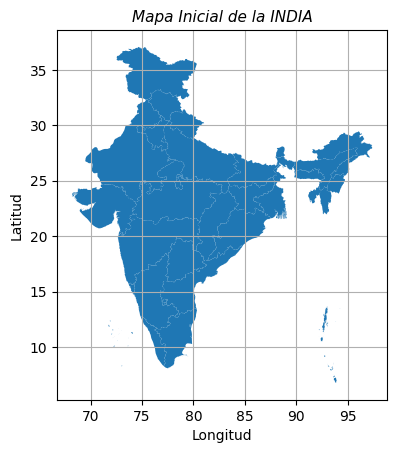

In [ ]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

- This first map shows the base geometry of the states of India, not yet colored by quality level.
- It serves as a visual verification that the shapefile was loaded correctly and that the longitude/latitude axes are well defined.
- The states in gray represent the spatial reference upon which the WQI index is then overlaid.
- The following visualization adds color by WQI ranges and labels to better interpret water quality by state.

- Este primer mapa muestra la geometría base de los estados de la India, sin colorear todavía por nivel de calidad.
- Sirve como verificación visual de que el shapefile se cargó correctamente y de que los ejes de longitud/latitud están bien definidos.
- Los estados en gris representan la referencia espacial sobre la que luego se superpone el índice WQI.
- En la siguiente visualización se agrega color por rangos de WQI y etiquetas para interpretar mejor la calidad del agua por estado.

#### Label Overlay (States)

The labels of the states of India are overlaid on the map below. If several labels are close together, their position is adjusted to improve readability.

#### Superposición de etiquetas (estados)

A continuación se superponen las etiquetas de los estados de la India sobre el mapa. Si varias etiquetas quedan muy juntas, se ajusta su posición para mejorar la legibilidad.

In [ ]:
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


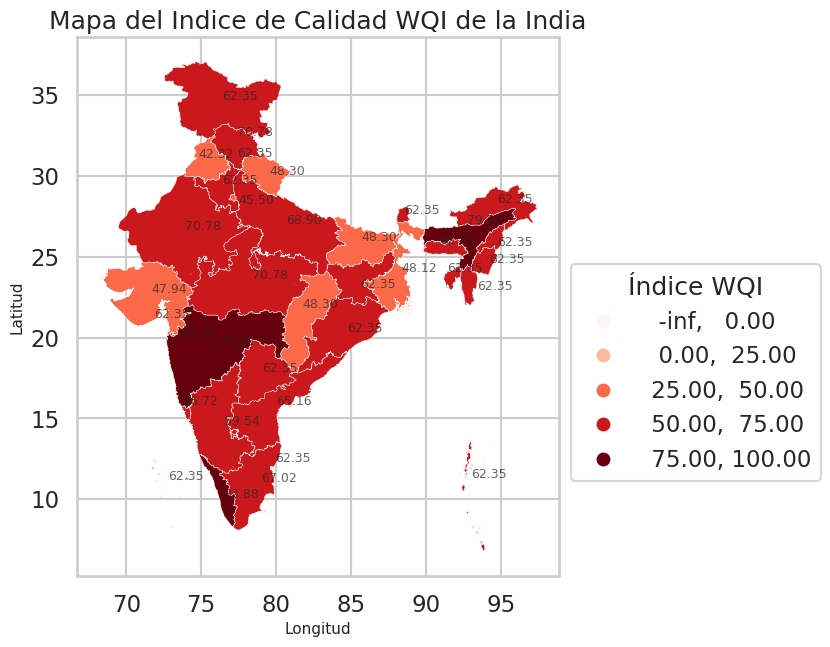

In [ ]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

- This map represents the Water Quality Index (WQI) by state using a red color scale.
- Lighter tones indicate better relative conditions, while more intense tones reflect higher WQI values ​​(more compromised quality according to defined intervals).
- The legend is divided by reference ranges (`0-25`, `25-50`, `50-75`, `75-100`) to facilitate visual interpretation.
- Numeric labels above each state show the estimated WQI value and allow you to quickly compare neighboring regions.
- This visualization summarizes the spatial result of the analysis and helps identify areas where review or intervention should be prioritized.

- Este mapa representa el índice de calidad del agua (WQI) por estado usando una escala de color en tonos rojos.
- Los tonos más claros indican mejores condiciones relativas, mientras que los tonos más intensos reflejan valores de WQI más altos (calidad más comprometida según los intervalos definidos).
- La leyenda está dividida por rangos de referencia (`0-25`, `25-50`, `50-75`, `75-100`) para facilitar la interpretación visual.
- Las etiquetas numéricas sobre cada estado muestran el valor estimado de WQI y permiten comparar rápidamente regiones vecinas.
- Esta visualización resume el resultado espacial del análisis y ayuda a identificar zonas donde conviene priorizar revisión o intervención.

### **WQI Histogram by State**

### **Histograma de WQI por Estado**

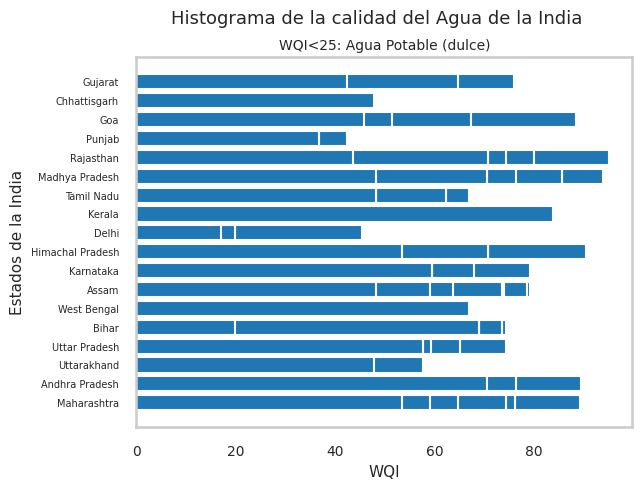

In [ ]:
df06.createOrReplaceTempView("df06_sql")

# Consolidar por estado para evitar barras repetidas y lograr un orden real
df_hist = sparkMunoz.sql("""
    SELECT STATE, AVG(WQI) AS WQI
    FROM df06_sql
    WHERE STATE IS NOT NULL AND WQI IS NOT NULL
    GROUP BY STATE
""").toPandas()

# Ordenar por WQI de menor a mayor
df_hist = df_hist.sort_values("WQI", ascending=True).reset_index(drop=True)

def categoria_wqi(valor):
    if valor < 25:
        return "Excelente"
    if valor < 50:
        return "Buena"
    if valor < 75:
        return "Baja"
    if valor < 100:
        return "Muy_Baja"
    return "Inadecuada"

colores_categoria = {
    "Excelente": "#2E7D32",
    "Buena": "#F9A825",
    "Baja": "#EF6C00",
    "Muy_Baja": "#C62828",
    "Inadecuada": "#6A1B9A"
}

df_hist["Categoria"] = df_hist["WQI"].apply(categoria_wqi)
colores = df_hist["Categoria"].map(colores_categoria)

# Altura dinámica para evitar saturación de etiquetas del eje Y
alto_figura = max(8, 0.38 * len(df_hist))
plt.figure(figsize=(12, alto_figura))
plt.barh(
    df_hist["STATE"],
    df_hist["WQI"],
    color=colores,
    edgecolor="black",
    linewidth=0.3
)

# Umbral de referencia principal
plt.axvline(25, color="black", linestyle="--", linewidth=1.1, alpha=0.8, label="Umbral WQI = 25")

plt.suptitle("Histograma de la Calidad del Agua en la India", fontsize=14)
plt.title("WQI promedio por estado (ordenado de menor a mayor)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=8)
plt.grid(axis="x", linestyle="--", alpha=0.35)

# Leyenda por categorías
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colores_categoria[cat])
    for cat in ["Excelente", "Buena", "Baja", "Muy_Baja", "Inadecuada"]
]
labels = [
    "Excelente (0-25)",
    "Buena [25-50)",
    "Baja [50-75)",
    "Muy_Baja [75-100)",
    "Inadecuada (>=100)"
 ]
plt.legend(handles, labels, title="Rangos WQI", loc="lower right", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()



- This horizontal histogram compares the WQI index between states and is ordered from lowest to highest value to make it easy to read the relative best to worst case scenario.
- The colors of the bars represent the quality category according to the reference ranges (`0-25`, `25-50`, `50-75`, `75-100`, `>=100`).
- The dotted vertical line at `WQI = 25` marks the reference threshold associated with the best condition range (fresh/drinking water in this exercise).
- The numerical labels at the end of each bar show the exact estimated WQI value and allow direct comparisons between nearby states.
- This visualization quickly summarizes the territorial distribution of the WQI and helps prioritize states with higher values ​​for analysis or intervention.



- Este histograma horizontal compara el índice WQI entre estados y está ordenado de menor a mayor valor para facilitar la lectura del mejor al peor escenario relativo.
- Los colores de las barras representan la categoría de calidad según los rangos de referencia (`0-25`, `25-50`, `50-75`, `75-100`, `>=100`).
- La línea vertical punteada en `WQI = 25` marca el umbral de referencia asociado al rango de mejor condición (agua dulce/potable en este ejercicio).
- Las etiquetas numéricas al final de cada barra muestran el valor exacto estimado de WQI y permiten comparaciones directas entre estados cercanos.
- Esta visualización resume de forma rápida la distribución territorial del WQI y ayuda a priorizar estados con valores más altos para análisis o intervención.

### **Model Creation: Water Quality in India**

In this part we seek to predict the WQI parameter from the calculated ranges of the parameters (qrPH, qrDO, qrCOND, qrBOD, qrNN, qrFecal).

First, the dataset is assembled with the input columns (features) and the target value (WQI). The data are then separated into training and testing. A simple neural network is then trained with Keras and the behavior is reviewed with a loss graph and a comparison between actual and predicted values.

The idea is that this section is clear and reproducible, without adjusting hyperparameters in depth (that could be done in a next iteration).

### **Creación de Modelo: Calidad de Agua en la India**

En esta parte se busca predecir el parámetro WQI a partir de los rangos calculados de los parámetros (qrPH, qrDO, qrCOND, qrBOD, qrNN, qrFecal).

Primero se arma el dataset con las columnas de entrada (features) y el valor objetivo (WQI). Luego se separan los datos en entrenamiento y prueba. Después se entrena una red neuronal sencilla con Keras y se revisa el comportamiento con un gráfico de pérdida y una comparación entre valores reales y predichos.

La idea es que esta sección quede clara y sea reproducible, sin ajustar hiperparámetros a profundidad (eso se podría hacer en una iteración siguiente).

In [ ]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [ ]:
# Se requiere predecir el parámetro WQI.
# Para ello tomamos como entradas los rangos de calidad (qr*) y como salida el WQI.

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [ ]:
# Convertimos a Pandas para poder usar utilidades de scikit-learn (train/test split).
# Entrenamiento: 80%  |  Prueba: 20%

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(),
    dfPredecir.toPandas(),
    test_size=0.2,
    random_state=1
 )

In [ ]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [ ]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense, Input

In [ ]:
# Ajuste de parámetros: este ajuste es de forma estándar.
# Para un mejor desempeño se requiere un estudio más profundo de hiperparámetros.
# Lo siguiente sirve como guía metodológica/académica para abordar un modelo de predicción.

epocas = 200
lote = 81

# Se inicializa el modelo con sus capas (usando Input para evitar warnings de Keras)
modelo01 = Sequential()
modelo01.add(Input(shape=(6,)))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(1, activation='linear'))

In [ ]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [ ]:
modelo01.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo (manteniendo la configuración original del experimento)
ejecutarK = modelo01.fit(
    dataTrain,
    predTrain,
    epochs=epocas,
    batch_size=lote
 )

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1143.4305 - mse: 1143.4305
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 185.8460 - mse: 185.8460 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 56.7105 - mse: 56.7105 
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25.1105 - mse: 25.1105 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 10.4205 - mse: 10.4205
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.4549 - mse: 5.4549 
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.6079 - mse: 3.6079 
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.9081 - mse: 1.9081 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.4415 - mse: 1.4415
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8450 - mse: 0.8450
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4529 - mse: 0.4529 
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2951 - mse: 0.2951  
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━

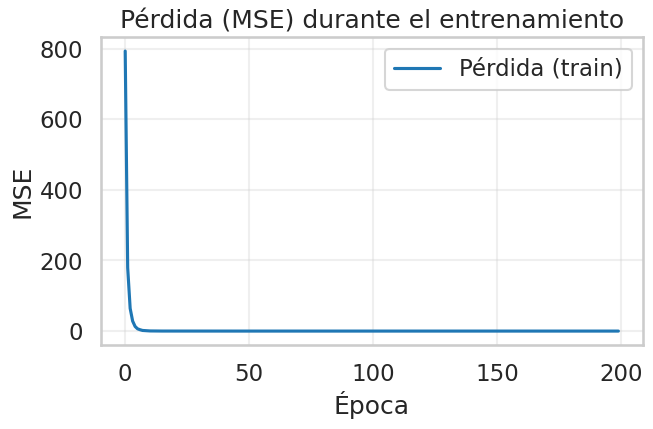

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'], label='Pérdida (train)')
plt.title('Pérdida (MSE) durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- This graph shows the evolution of the loss (`MSE`) during the training of the model in each epoch.
- A downward trend indicates that the network is learning useful patterns from the input variables.
- If the curve flattens towards the end, it suggests convergence and that training many more epochs would provide marginal improvements.
- Strong variations or unstable peaks in the loss can signal training sensitivity and motivate hyperparameter tuning.
- This visualization serves to validate that the training process was consistent before evaluating predictions in detail.

- Esta gráfica muestra la evolución de la pérdida (`MSE`) durante el entrenamiento del modelo en cada época.
- Una tendencia descendente indica que la red está aprendiendo patrones útiles a partir de las variables de entrada.
- Si la curva se aplana hacia el final, sugiere convergencia y que entrenar muchas más épocas aportaría mejoras marginales.
- Variaciones fuertes o picos inestables en la pérdida pueden señalar sensibilidad del entrenamiento y motivar ajuste de hiperparámetros.
- Esta visualización sirve para validar que el proceso de entrenamiento fue consistente antes de evaluar predicciones en detalle.

In [ ]:
### Predicción sobre datos de entrenamiento
X_train = dataTrain.to_numpy()
y_train = predTrain.to_numpy().reshape(-1)
predModelo01_Train = modelo01.predict(X_train, verbose=0).reshape(-1)

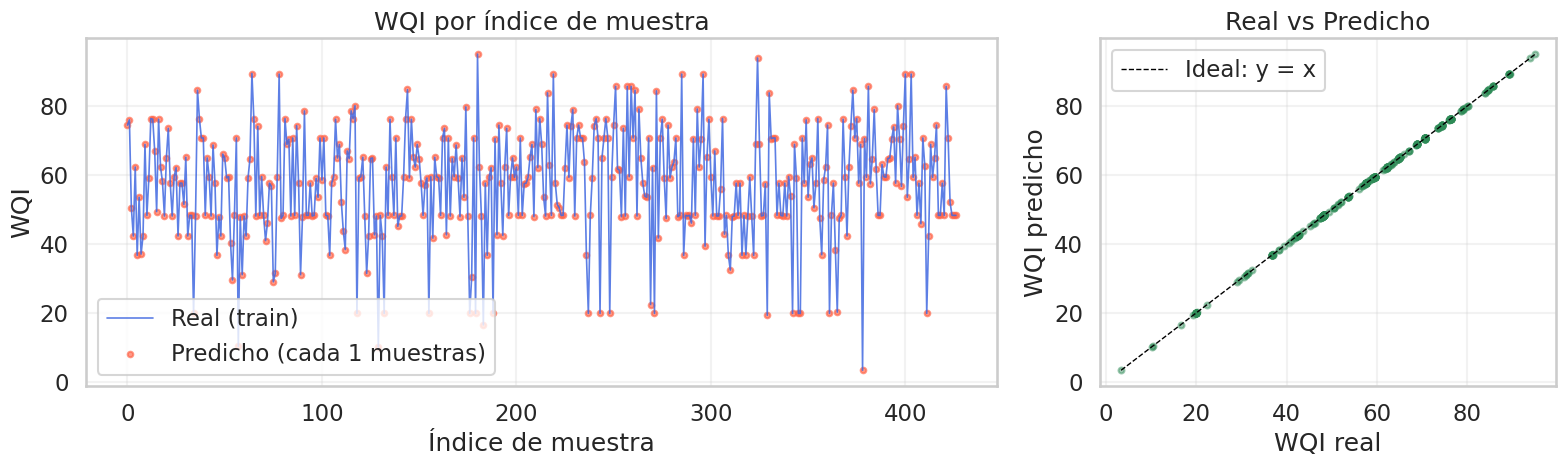

In [ ]:
### Comparación mejorada: real vs. predicho (entrenamiento)
idx = np.arange(len(y_train))
paso = max(1, len(y_train) // 250)  # Muestreo para que no se amontonen los marcadores

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]}
 )

# Panel 1: serie temporal (índice de muestra)
ax1.plot(idx, y_train, color='royalblue', linewidth=1.2, alpha=0.85, label='Real (train)')
ax1.scatter(
    idx[::paso],
    predModelo01_Train[::paso],
    color='tomato',
    s=16,
    alpha=0.65,
    label=f'Predicho (cada {paso} muestras)'
 )
ax1.set_title('WQI por índice de muestra')
ax1.set_xlabel('Índice de muestra')
ax1.set_ylabel('WQI')
ax1.grid(True, alpha=0.25)
ax1.legend()

# Panel 2: dispersión Real vs Predicho
ax2.scatter(y_train, predModelo01_Train, color='seagreen', s=18, alpha=0.45)
vmin = float(min(y_train.min(), predModelo01_Train.min()))
vmax = float(max(y_train.max(), predModelo01_Train.max()))
ax2.plot([vmin, vmax], [vmin, vmax], 'k--', linewidth=1, label='Ideal: y = x')
ax2.set_title('Real vs Predicho')
ax2.set_xlabel('WQI real')
ax2.set_ylabel('WQI predicho')
ax2.grid(True, alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

- The left panel compares the actual WQI versus the predicted WQI across the training sample index.
- The closer the predicted points are to the actual curve, the better the model fits on the data used for training.
- The right panel (actual vs. predicted dispersion) summarizes that fit: a cloud close to the ideal line `y = x` indicates good predictability.
- Wide dispersion with respect to the diagonal reflects estimation errors and possible opportunities to improve architecture or parameters.
- This figure allows you to visually evaluate model accuracy and bias before moving on to more formal numerical metrics.

- El panel izquierdo compara el WQI real frente al WQI predicho a lo largo del índice de muestra en entrenamiento.
- Cuanto más cerca estén los puntos predichos de la curva real, mejor es el ajuste del modelo sobre los datos usados para entrenar.
- El panel derecho (dispersión real vs predicho) resume ese ajuste: una nube cercana a la línea ideal `y = x` indica buena capacidad de predicción.
- Dispersión amplia respecto a la diagonal refleja errores de estimación y posibles oportunidades de mejorar arquitectura o parámetros.
- Esta figura permite evaluar visualmente precisión y sesgo del modelo antes de pasar a métricas numéricas más formales.

### **ADDED: Validation, Baselines and WQI Sensitivity**

### **AGREGADO: Validación, Baselines y Sensibilidad WQI**

In [ ]:

import builtins# 1) Dataset para modelado
columnas_x = ["qrPH", "qrDO", "qrCOND", "qrBOD", "qrNN", "qrFecal"]
target_y = "WQI"

df_modelo = df06.select(*(columnas_x + [target_y])).toPandas().dropna()
X = df_modelo[columnas_x]
y = df_modelo[target_y]

# Split explícito de entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

# 2) Modelos base para comparación
modelos = {
    "Regresión Lineal": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    )
}

# 3) Validación cruzada (5-fold) con MAE, RMSE y R2
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

resultados_cv = []
resultados_test = []

for nombre, modelo in modelos.items():
    cv_out = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultados_cv.append({
        "Modelo": nombre,
        "CV_MAE": -cv_out["test_mae"].mean(),
        "CV_RMSE": -cv_out["test_rmse"].mean(),
        "CV_R2": cv_out["test_r2"].mean()
    })

    modelo.fit(X_train, y_train)
    pred_test = modelo.predict(X_test)
    resultados_test.append({
        "Modelo": nombre,
        "TEST_MAE": mean_absolute_error(y_test, pred_test),
        "TEST_RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
        "TEST_R2": r2_score(y_test, pred_test)
    })

df_cv = pd.DataFrame(resultados_cv).sort_values(by="CV_RMSE")
df_test = pd.DataFrame(resultados_test).sort_values(by="TEST_RMSE")

print("=== Validación Cruzada (5-fold) ===")
display(df_cv.style.format({
    "CV_MAE": "{:.4f}", "CV_RMSE": "{:.4f}", "CV_R2": "{:.4f}"
}))

print("\n=== Evaluación Explícita en Conjunto de Prueba ===")
display(df_test.style.format({
    "TEST_MAE": "{:.4f}", "TEST_RMSE": "{:.4f}", "TEST_R2": "{:.4f}"
}))

# 4) Análisis de sensibilidad de pesos WQI
# Pesos base usados en el cálculo del WQI del notebook
pesos_base = {
    "qrPH": 0.165,
    "qrDO": 0.281,
    "qrCOND": 0.234,
    "qrBOD": 0.009,
    "qrNN": 0.028,
    "qrFecal": 0.281
}

def calcular_wqi(df_in, pesos):
    acumulado = np.zeros(len(df_in), dtype=float)
    for c in columnas_x:
        acumulado += df_in[c].to_numpy() * pesos[c]
    return acumulado

wqi_base = calcular_wqi(df_modelo, pesos_base)

sensibilidad = []
for c in columnas_x:
    for factor in [0.9, 1.1]:
        pesos_pert = pesos_base.copy()
        pesos_pert[c] = pesos_base[c] * factor

        # Normalización para mantener suma total de pesos constante
        suma_base = builtins.sum(pesos_base.values())
        suma_pert = builtins.sum(pesos_pert.values())
        for k in pesos_pert:
            pesos_pert[k] = pesos_pert[k] * (suma_base / suma_pert)

        wqi_pert = calcular_wqi(df_modelo, pesos_pert)
        delta_abs = np.mean(np.abs(wqi_pert - wqi_base))
        delta_rel = 100 * np.mean(np.abs((wqi_pert - wqi_base) / (wqi_base + 1e-9)))

        sensibilidad.append({
            "Parametro": c,
            "Escenario": f"{int((factor - 1) * 100):+d}% en su peso",
            "Delta_WQI_MAE": delta_abs,
            "Delta_WQI_pct_prom": delta_rel
        })

df_sens = pd.DataFrame(sensibilidad).sort_values(
    by=["Delta_WQI_MAE", "Delta_WQI_pct_prom"], ascending=False
 )

print("\n=== Sensibilidad de pesos del WQI (perturbacion +/-10%) ===")
display(df_sens.style.format({
    "Delta_WQI_MAE": "{:.4f}",
    "Delta_WQI_pct_prom": "{:.4f}%"
}))

print("\nTop 6 escenarios de mayor impacto:")
display(df_sens.head(6))

- This block was an addition that I put in to strengthen the evaluation part of the model and not be left with just the visual training inspection.
- A modeling set is first constructed with variables `qr*` as input and `WQI` as output, and then separated into training/testing to measure out-of-sample performance.
- Cross validation of 5 partitions is then executed to estimate stability with three metrics: `MAE`, `RMSE` and `R²`.
- In addition, three baselines are compared (`Linear Regression`, `Decision Tree` and `Random Forest`) to have an objective performance reference.
- In parallel, a sensitivity analysis of the WQI is included, disturbing the weights of each parameter by ±10% and normalizing the total sum, in order to identify which weights impact the final index the most.
- With this addition, the evaluation goes from being only descriptive to being quantitative and comparative, which I believe improves the methodological soundness.

- Este bloque fue un agreagdo que puse para fortalecer la parte de evaluación del modelo y no quedarnos solo con la inspección visual de entrenamiento.
- Primero se construye un conjunto de modelado con variables `qr*` como entrada y `WQI` como salida, y luego se separa en entrenamiento/prueba para medir desempeño fuera de muestra.
- Después se ejecuta validación cruzada de 5 particiones para estimar estabilidad con tres métricas: `MAE`, `RMSE` y `R²`.
- Además se comparan tres baselines (`Regresión Lineal`, `Árbol de Decisión` y `Random Forest`) para tener una referencia objetiva de desempeño.
- En paralelo se incluye un análisis de sensibilidad del WQI perturbando ±10% los pesos de cada parámetro y normalizando la suma total, con el fin de identificar qué pesos impactan más el índice final.
- Con este agregado, la evaluación pasa de ser solo descriptiva a ser cuantitativa y comparativa, lo que creo, mejora la solidez metodológica.

### **Conclusions**

- The exercise demonstrates a complete and reproducible roadmap for water quality analysis: data ingestion, cleaning, WQI index construction, spatial visualization and predictive modeling with Keras.
- The preprocessing stage was decisive for the consistency of the analysis. Type normalization, null validation, and geographic name homologation allowed the tabular data to be correctly integrated with the geospatial component.
- The construction of the WQI allowed multiple physicochemical parameters to be transformed into an interpretable synthetic metric, useful for comparing territories and prioritizing technical reviews by state.
- The visualizations (map and ordered histogram) facilitated the reading of regional patterns and showed relative differences between states, providing value for exploratory analysis and communication of results.
- The neural model managed to capture the relationship between input variables and WQI in training; however, this result should be interpreted with caution and not as conclusive evidence of generalization without robust external validation.
- As a main limitation, the study depends on a limited data set and fixed weighting rules from the literature. Consequently, the results are methodologically valid, but they do not replace official verification.

In summary, the document meets its training objective by integrating data processing at scale, geospatial analytics and machine learning in a single pipeline, leaving a serious technical foundation for future iterations with applied scope.

### **Conclusiones**

- El ejercicio demuestra una ruta de trabajo completa y reproducible para análisis de calidad de agua: ingestión de datos, limpieza, construcción del índice WQI, visualización espacial y modelado predictivo con Keras.
- La etapa de preprocesamiento fue determinante para la consistencia del análisis. La normalización de tipos, la validación de nulos y la homologación de nombres geográficos permitieron integrar correctamente los datos tabulares con el componente geoespacial.
- La construcción del WQI permitió transformar múltiples parámetros fisicoquímicos en una métrica sintética interpretable, útil para comparar territorios y priorizar revisiones técnicas por estado.
- Las visualizaciones (mapa e histograma ordenado) facilitaron la lectura de patrones regionales y evidenciaron diferencias relativas entre estados, aportando valor para análisis exploratorio y comunicación de resultados.
- El modelo neuronal logró capturar relación entre variables de entrada y WQI en entrenamiento; sin embargo, este resultado debe interpretarse con prudencia y no como evidencia concluyente de generalización sin validación externa robusta.
- Como limitación principal, el estudio depende de un conjunto de datos acotado y de reglas de ponderación fijas de la literatura. En consecuencia, los resultados son metodológicamente válidos, pero pues no reemplazan una verificacion oficial.

En síntesis, el documento cumple su objetivo formativo al integrar procesamiento de datos a escala, analítica geoespacial y aprendizaje automático en un solo pipeline, dejando una base técnica seria para futuras iteraciones con alcance aplicado.